In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import torch

In [3]:
import os
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = hf_token
print("Hugging Face token successfully loaded!")

Hugging Face token successfully loaded!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
required_path = '/content/drive/MyDrive/new_data'

In [6]:
path = os.path.join(required_path,'new_train_df.csv')
train_df = pd.read_csv(path)
train_df.head()

,uid,MeSH,findings,impression,filename,label
0,3831,normal,Clear lungs. No infiltrates or suspicious pulm...,No acute cardiopulmonary abnormality.,3831_IM-1934-1001.dcm.png,normal
1,1673,Lung/hyperdistention,Heart size is normal in cardiomediastinal silh...,No acute cardiopulmonary abnormality,1673_IM-0444-1001.dcm.png,abnormal
2,2406,"Hernia, Hiatal/large",Both lungs remain clear and expanded. Heart an...,No change. No visible active cardiopulmonary d...,2406_IM-0954-1001.dcm.png,abnormal
3,404,Foreign Bodies/abdomen;Technical Quality of Im...,Artifact in the region of the central upper ab...,Limited exam secondary to artifact within the ...,404_IM-2052-1001.dcm.png,abnormal
4,1378,normal,Heart size is normal. Cardiomediastinal silhou...,Negative for acute abnormality.,1378_IM-0242-1001.dcm.png,normal


In [7]:
path = os.path.join(required_path,'new_val_df.csv')
val_df = pd.read_csv(path)
val_df.head()


,uid,MeSH,findings,impression,filename,label
0,2968,Mass/right/paratracheal,Right paratracheal stripe is denser and XXXX t...,"Right paratracheal mass, possibly lymphadenopa...",2968_IM-1360-1001.dcm.png,abnormal
1,3813,Opacity/lung/base/left,There is XXXX opacity left lung base may repre...,XXXX opacity left lung base..,3813_IM-1922-1001.dcm.png,abnormal
2,128,Granulomatous Disease;Lung/hyperdistention;Dia...,Sequelae of old granulomatous disease. Lungs a...,1. Overall stable appearance of the chest sugg...,128_IM-0186-82592001.dcm.png,abnormal
3,604,"Catheters, Indwelling/right",The heart size and pulmonary vascularity appea...,1. No evidence of active disease.,604_IM-2193-1001.dcm.png,abnormal
4,2778,"Catheters, Indwelling/right",The pulmonary nodules and masses masses on pre...,Interval decrease in size of numerous pulmonar...,2778_IM-1218-1001.dcm.png,abnormal


In [8]:
path = os.path.join(required_path,'new_test_df.csv')
test_df = pd.read_csv(path)
test_df.head()

,uid,MeSH,findings,impression,filename,label
0,3011,"Atherosclerosis/aorta;Hernia, Hiatal/large",Aortic atherosclerotic calcifications. Large h...,1. No acute pulmonary process. 2. Large hiatal...,3011_IM-1390-1001.dcm.png,abnormal
1,677,"Catheters, Indwelling/right;Lung/hypoinflation...",PICC line catheter tip XXXX in the right atriu...,In view of the history findings are strongly s...,677_IM-2249-1001.dcm.png,abnormal
2,3781,normal,"The lungs are clear bilaterally. Specifically,...",No acute cardiopulmonary abnormality.,3781_IM-1897-1001.dcm.png,normal
3,1729,Emphysema/bilateral/chronic/severe,Chronic bilateral emphysematous changes. The h...,Significant bilateral emphysematous changes. N...,1729_IM-0480-1001.dcm.png,abnormal
4,1149,Calcified Granuloma/lung/hilum/bilateral/multiple,Several calcified granulomas in bilateral hila...,1. No acute cardiopulmonary abnormality.,1149_IM-0101-1001.dcm.png,abnormal


In [9]:
train_df['label'] = (
    train_df['label']
    .str.strip()
    .str.lower()
    .map({'normal': 0, 'abnormal': 1})
)

val_df['label'] = (
    val_df['label']
    .str.strip()
    .str.lower()
    .map({'normal': 0, 'abnormal': 1})
)

test_df['label'] = (
    test_df['label']
    .str.strip()      #
    .str.lower()
    .map({'normal': 0, 'abnormal': 1})
)

In [10]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased",token = hf_token)

In [11]:
train_encodings = tokenizer(
    train_df['findings'].tolist(),
    padding = True,
    truncation = True,
    max_length = 512,
    return_tensors = 'pt'
)

val_encodings = tokenizer(
    val_df['findings'].tolist(),
    padding = True,
    truncation = True,
    max_length = 512,
    return_tensors = 'pt'
)

test_encodings = tokenizer(
    test_df['findings'].tolist(),
    padding = True,
    truncation = True,
    max_length = 512,
    return_tensors = 'pt'
)

In [12]:
from transformers import DistilBertForSequenceClassification
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
from transformers import TrainingArguments
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    lr_scheduler_type = 'cosine',
    learning_rate = 2e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    num_train_epochs = 3,
    weight_decay = 0.01,
    load_best_model_at_end=True
)

In [14]:
from torch.utils.data import Dataset
import torch

class ChestXrayDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {}

        for key, val in self.encodings.items():
            item[key] = torch.tensor(val[idx])

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)


In [15]:
train_dataset = ChestXrayDataset(train_encodings,train_df['label'].tolist())
val_dataset = ChestXrayDataset(val_encodings,val_df['label'].tolist())
test_dataset = ChestXrayDataset(test_encodings,test_df['label'].tolist())

In [18]:
from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset = val_dataset
)
trainer.train()

/tmp/ipykernel_5368/3776675020.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item[key] = torch.tensor(val[idx])


Epoch,Training Loss,Validation Loss
1,0.354252,0.190591
2,0.157163,0.126463
3,0.109947,0.122756


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_5368/3776675020.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item[key] = torch.tensor(val[idx])


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_5368/3776675020.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item[key] = torch.tensor(val[idx])


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=366, training_loss=0.20712084327239155, metrics={'train_runtime': 152.6977, 'train_samples_per_second': 38.252, 'train_steps_per_second': 2.397, 'total_flos': 374781317844384.0, 'train_loss': 0.20712084327239155, 'epoch': 3.0})

In [19]:
best_model_path = trainer.state.best_model_checkpoint

In [20]:
best_model_path

'/content/drive/MyDrive/results/checkpoint-366'

In [21]:
from sklearn.metrics import classification_report
predictions = trainer.predict(test_dataset)
predicted_labels = np.argmax(predictions.predictions,axis=1)
true_labels = test_df['label'].tolist()
print(classification_report(true_labels, predicted_labels))


/tmp/ipykernel_5368/3776675020.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item[key] = torch.tensor(val[idx])


              precision    recall  f1-score   support

           0       0.96      0.92      0.94        50
           1       0.98      0.99      0.98       194

    accuracy                           0.98       244
   macro avg       0.97      0.95      0.96       244
weighted avg       0.98      0.98      0.98       244



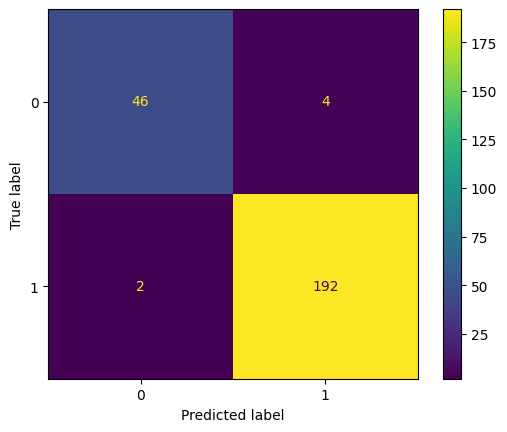

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(true_labels,predicted_labels)
plt.show()

In [23]:
from sklearn.metrics import roc_auc_score
ras = roc_auc_score(true_labels,predicted_labels)
ras

np.float64(0.9548453608247423)

In [27]:
from sklearn.metrics import roc_curve,auc,precision_recall_curve,average_precision_score


In [40]:
import torch.nn.functional as F
probs = F.softmax(torch.tensor(predictions.predictions), dim=1)
positive_class_probs = probs[:, 1].numpy()

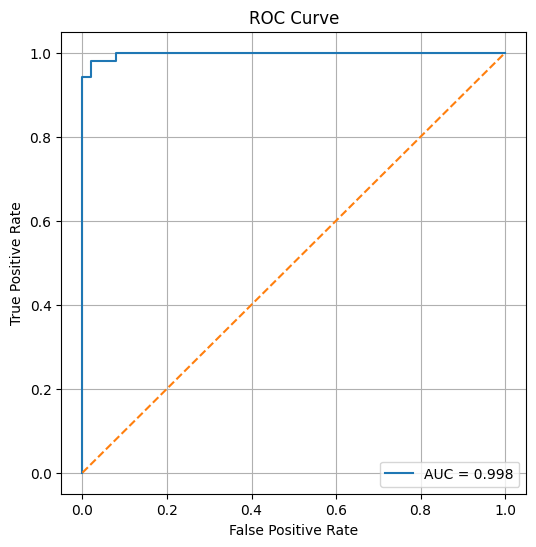

In [41]:
fpr,tpr,thresholds = roc_curve(true_labels,positive_class_probs)
roc_auc = auc(fpr,tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

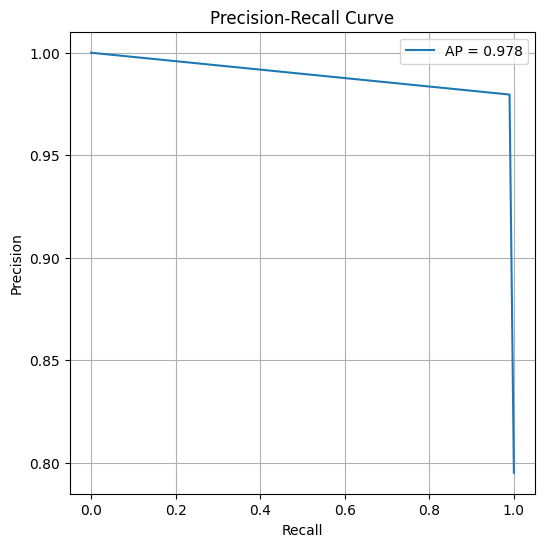

In [30]:
precision, recall, thresholds = precision_recall_curve(true_labels, predicted_labels)
ap = average_precision_score(true_labels, predicted_labels)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()